# JPSS VIIRS True Color — executed example

One VIIRS True Color image showing the **whole demonstration granule**.

> **This granule is not Shishaldin.** Satpy's public VIIRS demo granule is a
> Suomi NPP pass from 28 January 2017 over the western Mediterranean and North
> Africa, so no Alaskan island appears here. It is included to show the VIIRS
> workflow (spectral bands + matching geolocation). To render VIIRS over
> Shishaldin you must download real VIIRS SDR granules covering Alaska for your
> date and point `files` at them — the code below is unchanged.

VIIRS is an orbital swath, not a fixed grid, so its output is always placed on a
regular WGS84 longitude/latitude grid. Unlike ABI, VIIRS has a real green band,
so no synthetic green is needed.


## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
from IPython.display import Image, display
from satpy import Scene
from satpy.demo.viirs_sdr import get_viirs_sdr_20170128_1229

warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.render_satellite import (
    crop_and_resample_scene,
    has_viirs_geolocation,
    save_map,
)


## Parameters

In [2]:
DEMO_DATA_DIR = REPO_ROOT / "data" / "demo-viirs"
DEMO_CHANNELS = ("I01", "I02", "M03", "M04", "M05")
COMPOSITE = "true_color"

OUTPUT = REPO_ROOT / "output" / "viirs_true_color_granule.png"
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

# Longest side of the output image, in pixels. The grid spacing is derived from
# the granule size so the whole swath fits without a huge array.
TARGET_PIXELS = 1600


## Download the granule

The spectral bands and their matching geolocation files must come from the same
pass. `GITCO` (I bands) and `GMTCO` (M bands) are the terrain-corrected
geolocation files.


In [3]:
files = get_viirs_sdr_20170128_1229(
    base_dir=str(DEMO_DATA_DIR),
    channels=DEMO_CHANNELS,
    granules=(1,),
)
if not has_viirs_geolocation(files):
    raise FileNotFoundError("The matching VIIRS geolocation files are missing.")

print(f"VIIRS files: {len(files)}")


VIIRS files: 7


## Render the whole granule

The domain is taken from the granule's own longitude/latitude limits, so the
complete scene is shown and nothing is cut off at the edges.


The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


shape found from radius and resolution does not contain only integers: (453.28754894517925, 1599.9999999999818)
Rounding shape to (454, 1600) and resolution from (0.021958305239677678, 0.021958305239678566) meters to (0.021958305239677428, 0.021923846610317148) meters


granule domain: (-10.65, 31.0, 24.48, 40.95)
grid spacing: 0.0220 degrees


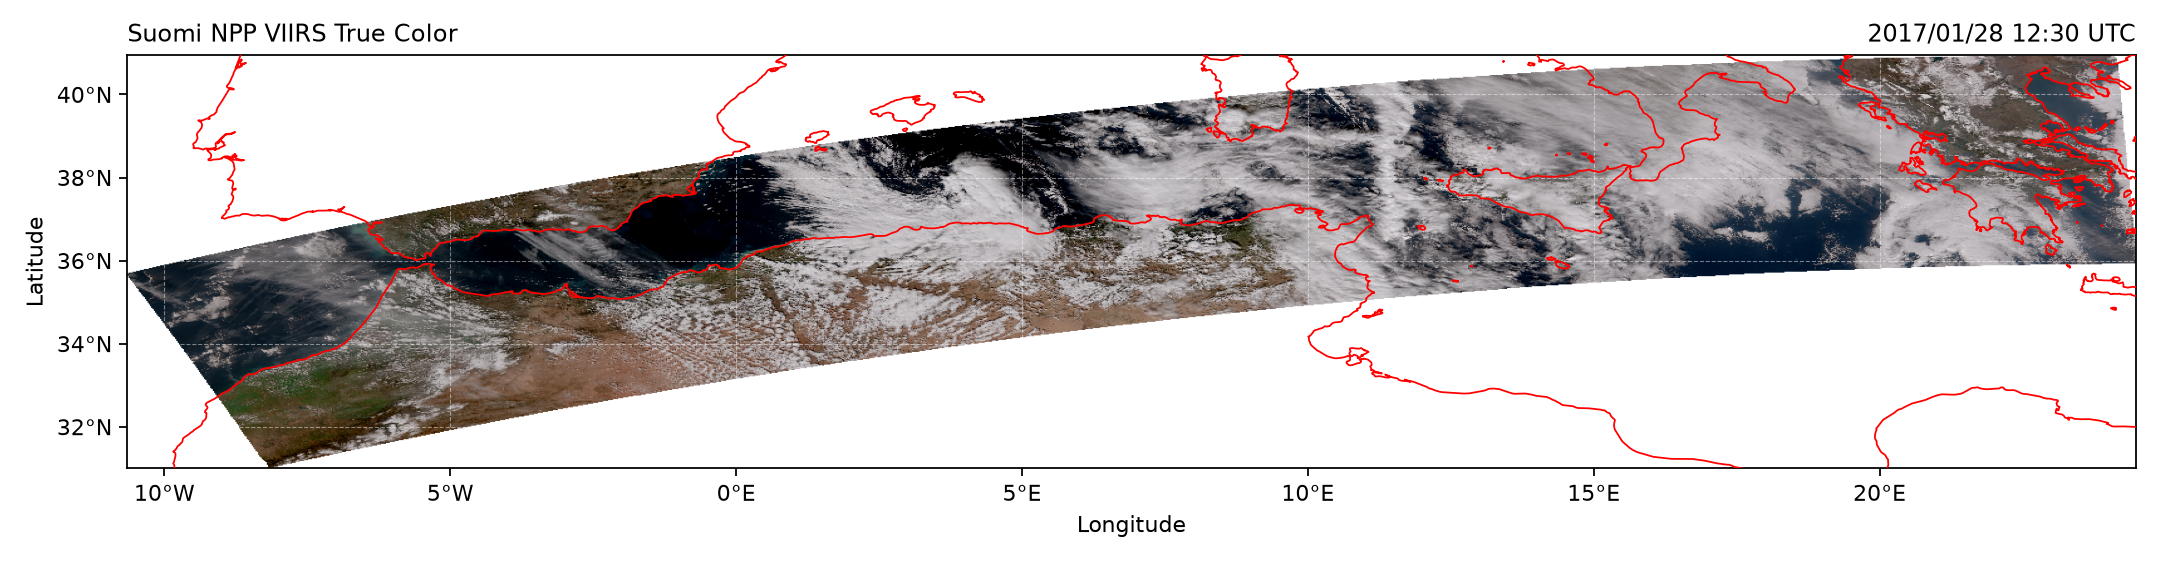

In [4]:
scene = Scene(reader="viirs_sdr", filenames=files)
scene.load([COMPOSITE], generate=True)

# Full extent of this granule, straight from its geolocation. The composite
# itself only exists after resampling, so read the swath from the loaded bands.
lons, lats = scene.coarsest_area().get_lonlats()
valid = np.isfinite(lons) & np.isfinite(lats)
DOMAIN = (
    float(np.min(lons[valid])), float(np.min(lats[valid])),
    float(np.max(lons[valid])), float(np.max(lats[valid])),
)
RESOLUTION = max(
    (DOMAIN[2] - DOMAIN[0]) / TARGET_PIXELS,
    (DOMAIN[3] - DOMAIN[1]) / TARGET_PIXELS,
)
print(f"granule domain: {tuple(round(v, 2) for v in DOMAIN)}")
print(f"grid spacing: {RESOLUTION:.4f} degrees")

output_scene = crop_and_resample_scene(
    scene, domain=DOMAIN, resolution=RESOLUTION
)
save_map(
    output_scene,
    COMPOSITE,
    OUTPUT,
    title="Suomi NPP VIIRS True Color",
)
display(Image(filename=str(OUTPUT)))


## Using VIIRS over Shishaldin

Replace the demo download with your own VIIRS SDR files for a pass that covers
the area, keeping the spectral bands and their geolocation together in one
directory:

```bash
python examples/render_satellite.py --sensor viirs \
    --files "data/viirs/*.h5" --composite true_color --domain shishaldin
```

VIIRS is polar-orbiting, so a given pass may not cover the island at the time
you want; check the granule geolocation before downloading. For continuous
coverage of Shishaldin use the GOES notebooks instead.
